In [139]:
#################################################################################
# Main script to run UP-MAVT analysis
#
# Simone Pagliuca, 2025-2026
#
# Description:
# TBC....
#################################################################################

#################################################################################
# Import third party libraries
import numpy as np
# import matplotlib
# matplotlib.use('TkAgg')  # Set backend before importing pyplot
import matplotlib.pyplot as plt
import seaborn as sns
import os
import csv
#################################################################################

#################################################################################
# Import internal modules
from pile_bwt import bwt, constraints_func
from up_mavt import startup, mc_simulation
from aggregation_methods import weighted_sum
from weight_sampling import obtain_weight_space_description
#################################################################################

#################################################################################
# USER INPUTS
# Weight elicitation files (one per elicitation / run)
file_path_weight_elicitations = ["wbt_results_1.csv"]
file_path_weight_elicitations = ["wbt_results_alt.csv"]


# Value function files (one per elicitation / run)
file_path_value_functions = ["value_functions_1.csv"]

# Criteria definitions file
file_path_criteria = "criteria.csv"

# Montecarlo Parameters
n_runs = 10000
PLOTS = True  # Toggle plots
UPDATE_EVERY = 10  # Update plots every N runs
#################################################################################


#################################################################################
# Startup: Load all data
dict_data_list, crit_index, vf_list, alternatives = startup(file_path_criteria, file_path_weight_elicitations, file_path_value_functions)
n_alternatives = len(alternatives)
print(f"Loaded {len(dict_data_list)} elicitation(s) with {n_alternatives} alternatives.")
#################################################################################


Number of criteria identified: 15
Loading criteria definitions and attaching value functions...
Starting loop over weight elicitation files...
Processing file 1/1: wbt_results_alt.csv
Loaded 1 elicitation(s) with 6 alternatives.


In [140]:

#################################################################################
# PILE-BWT Method
# 
# Work in progress while we try to fix issues with constraints and solver
# For now it runs the BWT optimization and then tries to sample more values from the space
print("Running BWT for each elicitation...")
bwt_results = []

for i, dict_data in enumerate(dict_data_list):
    print(f"Running BWT for elicitation {i+1}...")  # Debugging: Print elicitation index
    bwt_result = bwt(dict_data)
    bwt_results.append(bwt_result)
    
print(bwt_result["solver_result"])



Running BWT for each elicitation...
Running BWT for elicitation 1...
Running optimization...
     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 7.428143923925182
           x: [ 1.703e-01  1.732e-01 ...  5.950e-02  7.428e+00]
         nit: 22
         jac: [ 0.000e+00  0.000e+00 ...  0.000e+00  1.000e+00]
        nfev: 354
        njev: 20
 multipliers: [ 3.552e-08  0.000e+00 ...  6.489e-02  0.000e+00]


In [141]:

print("\033[93mTesting with BWT results...\033[0m")
x_weights = bwt_result["solver_result"]["x"][:-1]
x_temp = np.concatenate([x_weights, [0]])
constraint_value = constraints_func(x_temp, dict_data)
error_b = min(max([abs(cv) for cv in constraint_value]), 10)
for c in constraint_value:
    c_py = float(c)
    print(c_py)  # Debugging: print as native Python float
print(f"\033[91mMaximum constraint violation (error_b): {error_b}\033[0m")  # Debugging
known_max_error = error_b
print("\n")
print(x_weights)


Testing with BWT results...
-2.590126644219206
-2.569891455880241
-7.428143934293935
-7.428144176015184
-7.428144188831465
-5.3111659598488945
-0.24115409358051232
-4.837821597630499
-2.262439921894959
-7.428143958164051
-0.48983279058869655
-0.7935072085629562
-7.428143903358492
-5.396589980850896
-5.016378810057065
-0.2356548836803949
-0.257310928942299
-7.428143636419787
-0.6607894829918315
-0.44611972467334216
-2.289079803233991
-7.428143715313295
-6.84009428417419
-2.510995955415728
-7.371092137949825
-0.7147076330963014
-7.42814400370052
-4.7573299429308635
Maximum constraint violation (error_b): 7.428144188831465


[0.17034514 0.17319285 0.1697015  0.01955497 0.1055062  0.01608079
 0.10459729 0.00150226 0.0132272  0.02842384 0.01013897 0.06155606
 0.06052848 0.00614093 0.05950352]


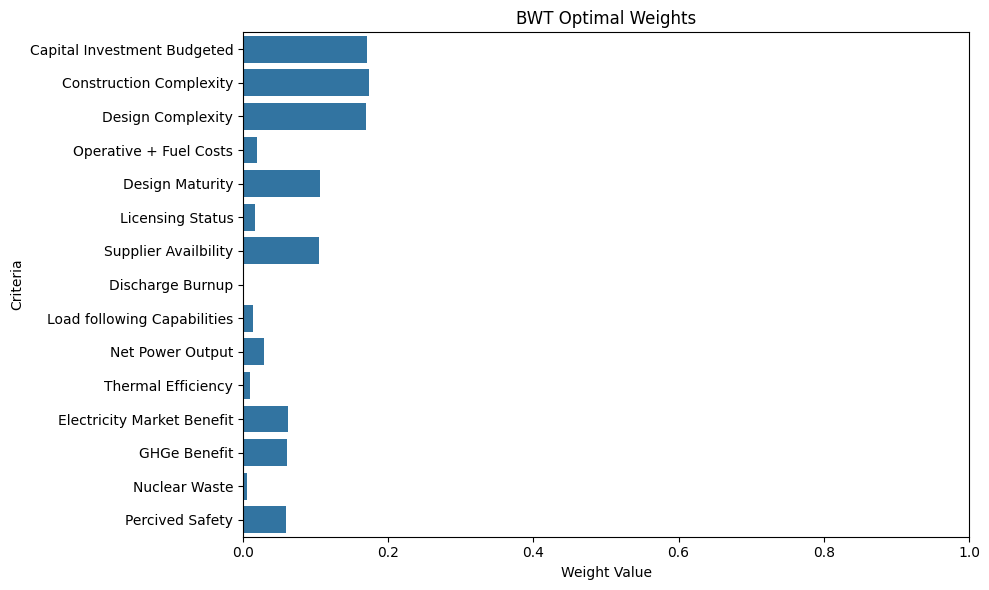

In [142]:
# Plot the BWT weights as horizontal bars
plt.figure(figsize=(10, 6))
sns.barplot(y=list(crit_index.keys()), x=x_weights, orient='h')
plt.title("BWT Optimal Weights")
plt.xlabel("Weight Value")
plt.ylabel("Criteria")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()
#################################################################################

In [143]:

from weight_sampling import obtain_weight_space_description
num_criteria = len(x_weights)
used_cells = set()
grid_size = np.int64(1000)
n_dimensions = num_criteria
# print("Number of dimensions for sampling:", n_dimensions)
nx = np.array([grid_size] * n_dimensions, dtype=np.int64)

initial_point = bwt_result["solver_result"]["x"][:num_criteria]
# print("Initial point for sampling:", initial_point)
initial_cell = tuple(np.clip((np.array(initial_point) * grid_size).astype(np.int64), 0, grid_size - 1))
used_cells.add(initial_cell)
valid_points = [np.array(initial_cell, dtype=np.float64) / grid_size]

print("Starting space sampling...")
print(f"Grid size: {grid_size}, Number of dimensions: {n_dimensions}")
print(f"Initial point: {initial_point}, Initial cell: {initial_cell}")


Starting space sampling...
Grid size: 1000, Number of dimensions: 15
Initial point: [0.17034514 0.17319285 0.1697015  0.01955497 0.1055062  0.01608079
 0.10459729 0.00150226 0.0132272  0.02842384 0.01013897 0.06155606
 0.06052848 0.00614093 0.05950352], Initial cell: (np.int64(170), np.int64(173), np.int64(169), np.int64(19), np.int64(105), np.int64(16), np.int64(104), np.int64(1), np.int64(13), np.int64(28), np.int64(10), np.int64(61), np.int64(60), np.int64(6), np.int64(59))


In [144]:
print(sum(initial_point))

0.9999999999999999


In [145]:
print(known_max_error)

7.428144188831465


Generating weight samples for elicitation 1...
Running optimization...
Re-initializing x0 from known optimal solution without z_star constraint...
Running optimization...
Re-running with 'trust-constr' due to z_star constraint...
Running optimization...
Re-initializing x0 from known optimal solution without z_star constraint...
Running optimization...
Re-running with 'trust-constr' due to z_star constraint...


/home/simo/GitHub/Master-Thesis/.venv/lib/python3.13/site-packages/scipy/optimize/_differentiable_functions.py:376: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)
/home/simo/GitHub/Master-Thesis/.venv/lib/python3.13/site-packages/scipy/optimize/_differentiable_functions.py:728: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(delta_x, delta_g)


Running optimization...
Re-initializing x0 from known optimal solution without z_star constraint...
Running optimization...
Re-running with 'trust-constr' due to z_star constraint...
Running optimization...
Re-initializing x0 from known optimal solution without z_star constraint...
Running optimization...
Re-running with 'trust-constr' due to z_star constraint...
Running optimization...
Re-initializing x0 from known optimal solution without z_star constraint...
Running optimization...
Re-running with 'trust-constr' due to z_star constraint...
Running optimization...
Re-initializing x0 from known optimal solution without z_star constraint...
Running optimization...
Re-running with 'trust-constr' due to z_star constraint...
Running optimization...
Re-initializing x0 from known optimal solution without z_star constraint...
Running optimization...
Re-running with 'trust-constr' due to z_star constraint...
Running optimization...
Re-initializing x0 from known optimal solution without z_star

/home/simo/GitHub/Master-Thesis/.venv/lib/python3.13/site-packages/scipy/optimize/_differentiable_functions.py:376: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)
/home/simo/GitHub/Master-Thesis/.venv/lib/python3.13/site-packages/scipy/optimize/_differentiable_functions.py:728: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(delta_x, delta_g)


Running optimization...
Re-initializing x0 from known optimal solution without z_star constraint...
Running optimization...
Re-running with 'trust-constr' due to z_star constraint...
Running optimization...
Re-initializing x0 from known optimal solution without z_star constraint...
Running optimization...
Re-running with 'trust-constr' due to z_star constraint...
Running optimization...
Re-initializing x0 from known optimal solution without z_star constraint...
Running optimization...
Re-running with 'trust-constr' due to z_star constraint...
trust-constr failed (message: The maximum number of function evaluations is exceeded.)
Trying 'COBYQA' (SciPy) as fallback...
COBYQA failed (message: The maximum number of iterations has been exceeded)
Fallback to known optimal solution...
Running optimization...
Running optimization...
Re-initializing x0 from known optimal solution without z_star constraint...
Running optimization...
Re-running with 'trust-constr' due to z_star constraint...
Runn

...

Re-initializing x0 from known optimal solution without z_star constraint...
Running optimization...
Re-running with 'trust-constr' due to z_star constraint...
Running optimization...
Re-initializing x0 from known optimal solution without z_star constraint...
Running optimization...
Re-running with 'trust-constr' due to z_star constraint...
Running optimization...
Re-initializing x0 from known optimal solution without z_star constraint...
Running optimization...
Re-running with 'trust-constr' due to z_star constraint...
Running optimization...
Re-initializing x0 from known optimal solution without z_star constraint...
Running optimization...
Re-running with 'trust-constr' due to z_star constraint...
Running optimization...
Re-initializing x0 from known optimal solution without z_star constraint...
Running optimization...
Re-running with 'trust-constr' due to z_star constraint...
Running optimization...
Re-initializing x0 from known optimal solution without z_star constraint...
Running o

/home/simo/GitHub/Master-Thesis/.venv/lib/python3.13/site-packages/scipy/optimize/_differentiable_functions.py:376: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)
/home/simo/GitHub/Master-Thesis/.venv/lib/python3.13/site-packages/scipy/optimize/_differentiable_functions.py:728: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(delta_x, delta_g)


trust-constr failed (message: Constraint violation exceeds 'gtol')
Trying 'COBYQA' (SciPy) as fallback...
COBYQA failed (message: The maximum number of iterations has been exceeded)
Fallback to known optimal solution...
Running optimization...
Running optimization...
Re-initializing x0 from known optimal solution without z_star constraint...
Running optimization...
Re-running with 'trust-constr' due to z_star constraint...


/home/simo/GitHub/Master-Thesis/.venv/lib/python3.13/site-packages/scipy/optimize/_differentiable_functions.py:376: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)
/home/simo/GitHub/Master-Thesis/.venv/lib/python3.13/site-packages/scipy/optimize/_differentiable_functions.py:728: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(delta_x, delta_g)


Running optimization...
Re-initializing x0 from known optimal solution without z_star constraint...
Running optimization...
Re-running with 'trust-constr' due to z_star constraint...
Running optimization...
Re-initializing x0 from known optimal solution without z_star constraint...
Running optimization...
Re-running with 'trust-constr' due to z_star constraint...
Running optimization...
Re-initializing x0 from known optimal solution without z_star constraint...
Running optimization...
Re-running with 'trust-constr' due to z_star constraint...
Running optimization...
Re-initializing x0 from known optimal solution without z_star constraint...
Running optimization...
Re-running with 'trust-constr' due to z_star constraint...
trust-constr failed (message: Constraint violation exceeds 'gtol')
Trying 'COBYQA' (SciPy) as fallback...
COBYQA failed (message: The lower bound for the trust-region radius has been reached)
Fallback to known optimal solution...
Running optimization...


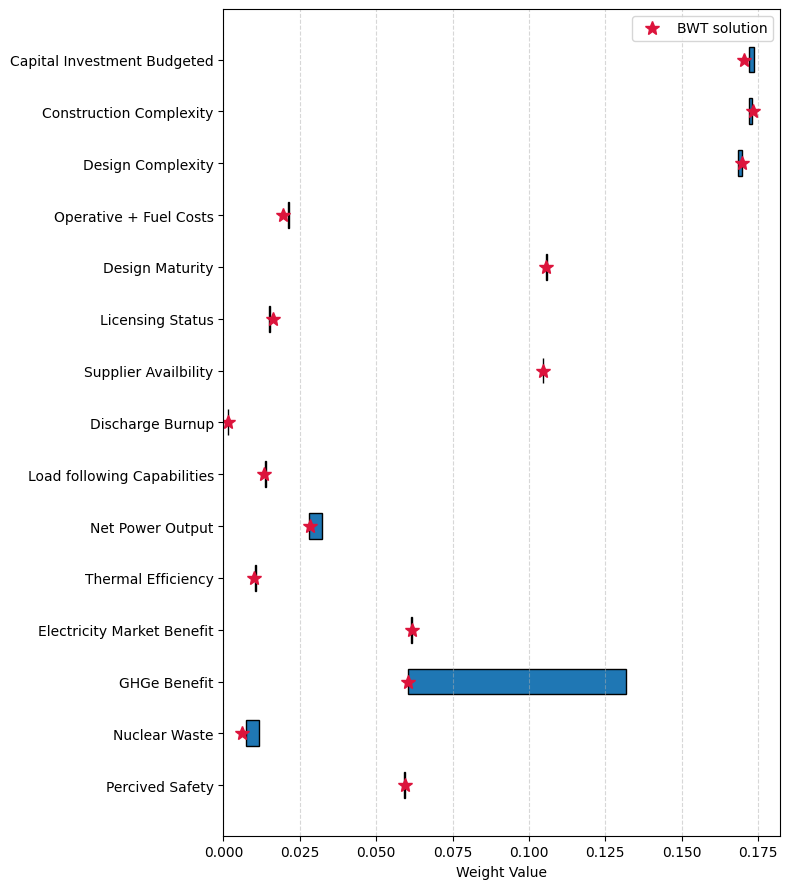

Total weight combinations to sample: 2160 (values rounded to 3 decimals)


In [146]:
list_of_weight_space_points = obtain_weight_space_description(bwt_results, dict_data_list, file_path_weight_elicitations, crit_index)

In [147]:
# We then seelct one of the elicitated spaces
weight_space_points = list_of_weight_space_points[0]
print(weight_space_points)

[[0.172, 0.173, 0.174], [np.float64(0.172)], [0.169, 0.17], [np.float64(0.021)], [np.float64(0.106)], [np.float64(0.015)], [np.float64(0.105)], [np.float64(0.002)], [np.float64(0.014)], [np.float64(0.03)], [np.float64(0.01)], [np.float64(0.061)], [0.061, 0.062, 0.063, 0.064, 0.065, 0.066, 0.067, 0.068, 0.069, 0.07, 0.071, 0.072, 0.073, 0.074, 0.075, 0.076, 0.077, 0.078, 0.079, 0.08, 0.081, 0.082, 0.083, 0.084, 0.085, 0.086, 0.087, 0.088, 0.089, 0.09, 0.091, 0.092, 0.093, 0.094, 0.095, 0.096, 0.097, 0.098, 0.099, 0.1, 0.101, 0.102, 0.103, 0.104, 0.105, 0.106, 0.107, 0.108, 0.109, 0.11, 0.111, 0.112, 0.113, 0.114, 0.115, 0.116, 0.117, 0.118, 0.119, 0.12, 0.121, 0.122, 0.123, 0.124, 0.125, 0.126, 0.127, 0.128, 0.129, 0.13, 0.131, 0.132], [0.008, 0.009, 0.01, 0.011, 0.012], [np.float64(0.059)]]


In [173]:
run = True
while run == True:
    rand_set = np.random.dirichlet(np.ones(num_criteria))
    x_to = np.concatenate([rand_set, [0]])
    cons = constraints_func(x_to, dict_data_list[0])
    error = (max([abs(c) for c in cons]))
    print(error)
    if all(c <= 0 for c in cons) and error <= known_max_error:
        print("Sampled point is valid:", rand_set)
        run = False

39.95161426695879
20.25473194715591
17.390219687060426
59.76454529507392
18.895248037626633
141.67123382761545
284.740041274804
16.50696463259531
19.9105700931992
44.6954531103117
38.32361195034066
19.6306280181961
17.409721904175655
18.68488289926146
93.70279020907236
47.57717973911554
16.595358959233927
20.081490993842873
20.124301385609762
238.87557866885487
19.98101037893699
17.078727241334843
1297.359956295401
15.21524308993412
31.332969594298742
73.42149161232155
19.92685320346274
115.90433379405005
12.006199577451476
19.18147296276406
41.98887086321196
19.560161360679416
47.72414111593058
43.4534854828213
20.18065461126347
19.76997429458567
16.275990873166368
1141.9577397228481
285.4402471073308
19.528904457674837
224.17541378380426
19.51039407655737
192.26068531564698
21.472892237760636
19.813633608807546
19.521909145089438
27.74127325989585
15.185241893785006
99.92467202222389
92.81990640584225
77.03223934228818
16.471798165903444
25.641874292406023
79.21955157050834
19.912176

KeyboardInterrupt: 

In [149]:
from weight_sampling import weight_sampler
weight_sampler(dict_data, weight_space_points)

KeyboardInterrupt: 